In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Loading the Data from the csv file & creating a dataframe

data = pd.read_csv('student_dataset_30.csv')
df = pd.DataFrame(data)

In [5]:
df

,Student_ID,Name,Gender,Age,Course,Python_Marks,NumPy_Marks,Attendance (%)
0,101,Anuj,Male,19,BCA,85,80,92
1,102,Riya,Female,20,BCA,92,90,96
2,103,Aman,Male,18,BSc,76,72,85
3,104,Priya,Female,21,BCA,88,91,98
4,105,Rahul,Male,20,BCom,69,65,80
5,106,Sneha,Female,19,BSc,95,97,99
6,107,Karan,Male,22,BCA,81,79,89
7,108,Neha,Female,18,BCom,74,70,83
8,109,Arjun,Male,21,BSc,90,88,95
9,110,Pooja,Female,20,BCA,87,84,91


## Data Exploration

In [6]:
Head = df.head()
Head

,Student_ID,Name,Gender,Age,Course,Python_Marks,NumPy_Marks,Attendance (%)
0,101,Anuj,Male,19,BCA,85,80,92
1,102,Riya,Female,20,BCA,92,90,96
2,103,Aman,Male,18,BSc,76,72,85
3,104,Priya,Female,21,BCA,88,91,98
4,105,Rahul,Male,20,BCom,69,65,80


In [7]:
Shape = df.shape
Shape

(30, 8)

In [8]:
Columns = df.columns
Columns

Index(['Student_ID', 'Name', 'Gender', 'Age', 'Course', 'Python_Marks',
       'NumPy_Marks', 'Attendance (%)'],
      dtype='object')

In [9]:
Dtype = df.dtypes
Dtype

Student_ID         int64
Name              object
Gender            object
Age                int64
Course            object
Python_Marks       int64
NumPy_Marks        int64
Attendance (%)     int64
dtype: object

## Data Cleaning

In [10]:
df.isna().sum()

Student_ID        0
Name              0
Gender            0
Age               0
Course            0
Python_Marks      0
NumPy_Marks       0
Attendance (%)    0
dtype: int64

In [11]:
# there are no null values
# there is no duplicate row
# numeric columns are numeric
df.duplicated().sum()

np.int64(0)

## Feature Engineering

* Average Marks
* Result(pass/fail)
* Grade


In [12]:
df['Average'] = (df['Python_Marks'] + df['NumPy_Marks'])/2

In [13]:
df['Result'] = np.where(df['Average'] > 40,"Pass","Fail")

## Analysis

In [14]:
Top_5 = df.sort_values(by='Average', ascending=False).head(5)
Top_5

,Student_ID,Name,Gender,Age,Course,Python_Marks,NumPy_Marks,Attendance (%),Average,Result
5,106,Sneha,Female,19,BSc,95,97,99,96.0,Pass
21,122,Tanya,Female,21,BCA,94,96,99,95.0,Pass
14,115,Mohit,Male,22,BSc,93,95,94,94.0,Pass
1,102,Riya,Female,20,BCA,92,90,96,91.0,Pass
26,127,Varun,Male,21,BSc,92,90,97,91.0,Pass


In [15]:
Bottom_5 = df.sort_values(by='Average', ascending=False).tail(5)
Bottom_5

,Student_ID,Name,Gender,Age,Course,Python_Marks,NumPy_Marks,Attendance (%),Average,Result
22,123,Harsh,Male,22,BCom,72,70,85,71.0,Pass
12,113,Rohit,Male,21,BCom,71,69,82,70.0,Pass
25,126,Sakshi,Female,19,BCom,70,68,80,69.0,Pass
4,105,Rahul,Male,20,BCom,69,65,80,67.0,Pass
15,116,Nisha,Female,19,BCom,68,66,81,67.0,Pass


In [16]:
highest_avg = df.nlargest(1,'Average')
highest_avg

,Student_ID,Name,Gender,Age,Course,Python_Marks,NumPy_Marks,Attendance (%),Average,Result
5,106,Sneha,Female,19,BSc,95,97,99,96.0,Pass


In [17]:
lowest_avg = df.nsmallest(1,'Average')
lowest_avg

,Student_ID,Name,Gender,Age,Course,Python_Marks,NumPy_Marks,Attendance (%),Average,Result
4,105,Rahul,Male,20,BCom,69,65,80,67.0,Pass


In [18]:
class_average = df['Average'].mean()
class_average

np.float64(81.9)

In [19]:
pass_percent = (df['Result']=='Pass').mean()*100
pass_percent

np.float64(100.0)

In [20]:
fail_percent = (df['Result'] == 'Fail').mean()*100
fail_percent

np.float64(0.0)

In [21]:
highest_att = df.nlargest(1,'Attendance (%)')
highest_att

,Student_ID,Name,Gender,Age,Course,Python_Marks,NumPy_Marks,Attendance (%),Average,Result
5,106,Sneha,Female,19,BSc,95,97,99,96.0,Pass


In [22]:
lowest_att = df.nsmallest(1,"Attendance (%)")
lowest_att

,Student_ID,Name,Gender,Age,Course,Python_Marks,NumPy_Marks,Attendance (%),Average,Result
4,105,Rahul,Male,20,BCom,69,65,80,67.0,Pass


In [23]:
gender_avg = df.groupby('Gender')['Average'].count()
gender_avg

Gender
Female    15
Male      15
Name: Average, dtype: int64

In [24]:
course_avg = df.groupby('Course')['Average'].count()
course_avg

Course
BCA     12
BCom     8
BSc     10
Name: Average, dtype: int64

## Numpy Integration

## Visualization

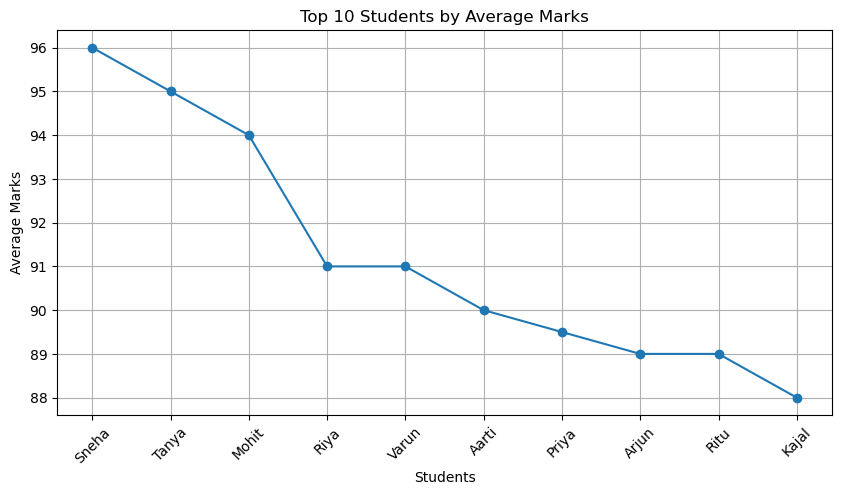

In [25]:
top10 = df.nlargest(10, 'Average')

plt.figure(figsize=(10,5))
plt.plot(top10['Name'], top10['Average'], marker='o')
plt.title("Top 10 Students by Average Marks")
plt.xlabel("Students")
plt.ylabel("Average Marks")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

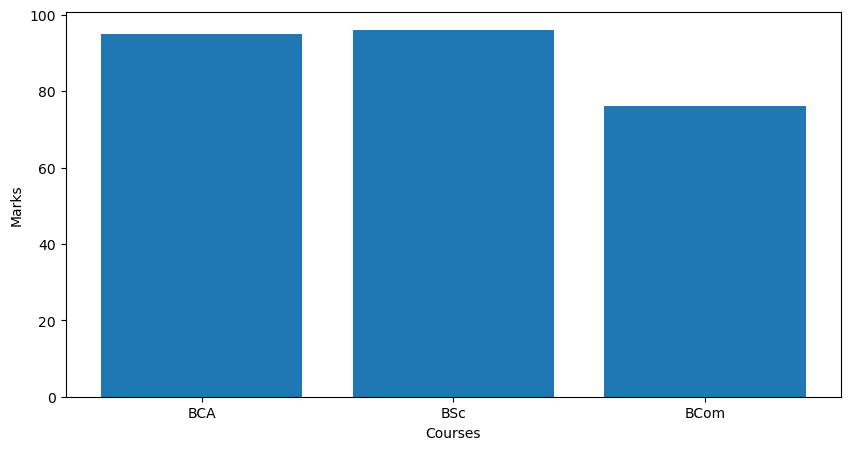

In [26]:
top_course = df.nlargest(10,'Average')

plt.figure(figsize=(10,5))
plt.bar(df['Course'],df['Average'])
plt.xlabel('Courses')
plt.ylabel('Marks')
plt.grid = True

plt.show()

## UseFul Insights

In [27]:
# Overall class average..
class_average

np.float64(81.9)

**highest permorming course?**
* B.Sc.

In [28]:
# girls/boys performed better in this dataset
# females perform better than male
df.groupby('Gender')['Average'].mean()

Gender
Female    84.0
Male      79.8
Name: Average, dtype: float64

In [91]:
#pass percentage

pass_percent

np.float64(100.0)

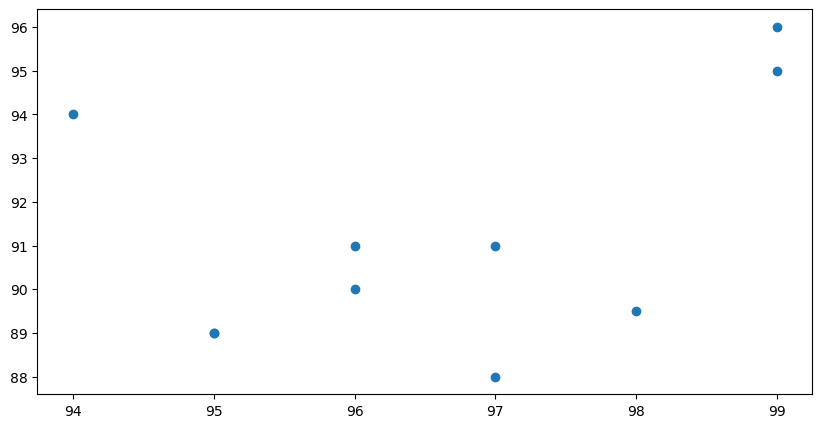

In [30]:
top_att = df.nlargest(10,'Average')
plt.figure(figsize=(10,5))
plt.scatter(top_att['Attendance (%)'],top_att['Average'],marker = "o")
plt.savefig('posi_negi_rel.png')



"The scatter plot shows a mixed trend between attendance and average marks. There is no clear positive or negative relationship. While some students with high attendance have high marks, others do not, suggesting that attendance alone does not strongly explain students' performance."